Dataset:  60 news items ( 30 fake, 30 real )

Average image features by class:
      Brightness  Contrast  Saturation  EdgeDensity  Red-Blue  Noise
Real      129.08     23.46      104.18         0.03      5.60  26.92
Fake      111.12     36.71      175.17         0.15     38.75  58.09

Text feature matrix      : (42, 487)
Image feature matrix     : (42, 6)
Multimodal feature matrix: (42, 493)

Model          Accuracy  Precision  Recall  F1-score
Text only      0.6667    0.6154     0.8889  0.7273
Image only     0.9444    0.9000     1.0000  0.9474
Multimodal     0.9444    0.9000     1.0000  0.9474

Confusion matrix (Multimodal model):
[[8 1]
 [0 9]]

Predictions on new examples:
Headline : Shocking secret cure doctors hide from you, share now
P(Fake)  : 0.992  ->  Fake News

Headline : Council approves new bus service for the city suburbs
P(Fake)  : 0.012  ->  Real News



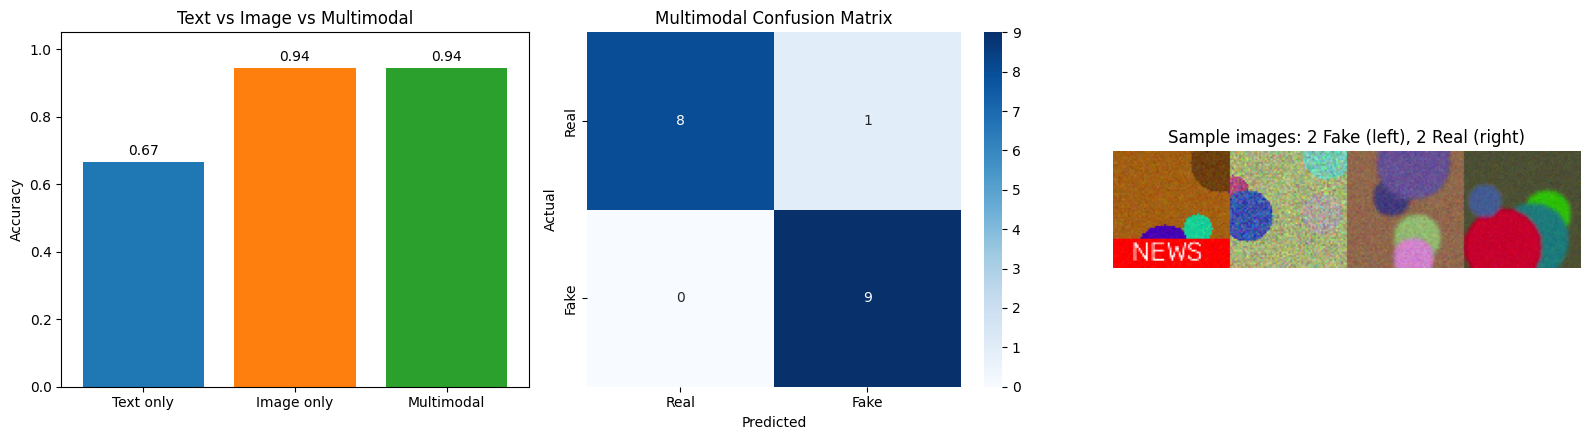

In [ ]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix

np.random.seed(7)

fake = [
    "SHOCKING: miracle fruit cures cancer in three days, doctors hate it",
    "You won't believe what the government is secretly hiding from you",
    "Celebrity found alive after fake death, media silent about the truth",
    "Drinking hot water with lemon destroys any virus instantly",
    "Aliens landed in the city last night, officials deny everything",
    "Free smartphones for everyone, just share this message ten times",
    "Secret document proves the moon landing was filmed in a studio",
    "Scientists admit vaccines contain tracking chips, whistleblower says",
    "Bank will close all accounts tomorrow, withdraw your money now",
    "Eating onions at night makes you lose ten kilos in a week",
    "Leaked video shows minister laughing at flood victims, share now",
    "5G towers cause sickness, hidden report reveals the horrifying truth",
    "Man gets rich overnight with this one weird trick banks fear",
    "Breaking: all schools to remain shut for one year, insiders claim",
    "Ancient herb reverses ageing, pharmaceutical companies want it banned",
    "Famous actor arrested for secret crime, mainstream news hides it",
    "Shocking cure for diabetes found in your kitchen, doctors stunned",
    "Government to ban all cash from midnight, forward to everyone",
    "Mysterious creature caught on camera, experts refuse to comment",
    "Viral photo proves the election was stolen, truth finally exposed",
    "Warning: this common food is poison, share before it is deleted",
    "Cricketer secretly retired, board hides the shocking reason",
    "Lottery company sends free cash to anyone who clicks this link",
    "Hidden planet will collide with earth next week, NASA covering up",
    "Local mayor caught with fortune, officials say report is a hoax",
    "Doctors stunned as common spice cures every disease overnight",
    "Chemicals in tap water turn people into zombies, leaked memo says",
    "Shocking truth about the new currency note chip, share immediately",
    "City to disappear under water by Friday, experts afraid to speak",
    "Government report says new bridge opens next month after repairs",
]

real = [
    "Government announces new scholarship scheme for rural students",
    "Researchers publish study on air quality improvement in cities",
    "Central bank keeps interest rates unchanged in its latest review",
    "Heavy rainfall expected in coastal regions, weather office says",
    "Local hospital opens new wing to treat more patients",
    "Parliament passes the budget after two days of debate",
    "Stock markets close higher as technology shares gain",
    "Engineers complete repair of the highway bridge ahead of schedule",
    "University announces dates for the annual entrance examination",
    "Health ministry reports decline in seasonal flu cases",
    "Cricket team wins the series after a close final match",
    "City council approves plan for new public park and library",
    "Scientists launch satellite to monitor monsoon patterns",
    "Railway department introduces new express train between two cities",
    "Farmers receive higher support price for wheat this season",
    "Company reports quarterly profit rise of five percent",
    "Metro services extended to the northern suburbs from Monday",
    "School board revises syllabus for the next academic year",
    "Police arrest two suspects in connection with the market theft",
    "Electric bus fleet to be added to the city transport service",
    "Doctors recommend regular exercise to reduce heart disease risk",
    "Election commission releases schedule for the state elections",
    "Museum opens exhibition on ancient trade routes this weekend",
    "Water supply to remain suspended for maintenance on Sunday",
    "Technology firm opens new research centre and hires graduates",
    "Officials confirm the shocking delay was caused by a signal failure",
    "Minister says the secret talks with farmers were productive",
    "Doctors warn that sharing unverified health tips can be harmful",
    "Students win national robotics competition held in the capital",
    "Airport adds new terminal to handle growing passenger traffic",
]

headlines = fake + real
labels = np.array([1] * len(fake) + [0] * len(real))

img_labels = list(labels) + [1, 0]
images = []
F_all = []

for l in img_labels:
    base = np.random.randint(60, 190, 3)

    # OpenCV drawing functions require uint8 images
    img = (np.ones((64, 64, 3), np.float32) * base).astype(np.uint8)

    for _ in range(4):
        cx, cy = np.random.randint(0, 64, 2)
        col = np.random.randint(40, 220, 3)

        cv2.circle(
            img,
            (int(cx), int(cy)),
            np.random.randint(8, 22),
            col.tolist(),
            -1
        )

    if l == 1:
        sat = np.random.uniform(1.0, 1.9)
        noise = np.random.uniform(8, 35)

        if np.random.rand() < 0.75:
            cv2.rectangle(
                img,
                (0, 48),
                (63, 63),
                (0, 0, 255),
                -1
            )

            cv2.putText(
                img,
                "NEWS",
                (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 255, 255),
                1
            )

    else:
        sat = np.random.uniform(0.5, 1.4)
        noise = np.random.uniform(2, 20)
        img = cv2.GaussianBlur(img, (5, 5), 0)

    hsv = cv2.cvtColor(
        np.clip(img, 0, 255).astype(np.uint8),
        cv2.COLOR_BGR2HSV
    ).astype(np.float32)

    hsv[..., 1] = np.clip(hsv[..., 1] * sat, 0, 255)

    img = cv2.cvtColor(
        hsv.astype(np.uint8),
        cv2.COLOR_HSV2BGR
    )

    img = img.astype(np.float32) + np.random.normal(
        0,
        noise,
        img.shape
    )

    img = np.clip(img, 0, 255).astype(np.uint8)

    images.append(img)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    edges = cv2.Canny(gray, 100, 200)

    F_all.append([
        gray.mean(),
        gray.std(),
        hsv[..., 1].mean(),
        (edges > 0).mean(),
        img[..., 2].mean() - img[..., 0].mean(),
        np.abs(cv2.Laplacian(gray, cv2.CV_64F)).mean()
    ])

F_all = np.array(F_all)

F_img = F_all[:60]
F_new = F_all[60:]

img_names = [
    'Brightness',
    'Contrast',
    'Saturation',
    'EdgeDensity',
    'Red-Blue',
    'Noise'
]

print(
    "Dataset: ",
    len(headlines),
    "news items (",
    labels.sum(),
    "fake,",
    (labels == 0).sum(),
    "real )"
)

print("\nAverage image features by class:")

print(
    pd.DataFrame(
        F_img,
        columns=img_names
    )
    .groupby(labels)
    .mean()
    .round(2)
    .rename(index={
        0: 'Real',
        1: 'Fake'
    })
)

idx = np.arange(len(headlines))

tr, te = train_test_split(
    idx,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

text_tr = [headlines[i] for i in tr]
text_te = [headlines[i] for i in te]

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2)
)

T_tr = tfidf.fit_transform(text_tr)
T_te = tfidf.transform(text_te)

scaler = StandardScaler()

I_tr = scaler.fit_transform(F_img[tr])
I_te = scaler.transform(F_img[te])

M_tr = hstack([
    T_tr,
    csr_matrix(I_tr)
]).tocsr()

M_te = hstack([
    T_te,
    csr_matrix(I_te)
]).tocsr()

print("\nText feature matrix      :", T_tr.shape)
print("Image feature matrix     :", I_tr.shape)
print("Multimodal feature matrix:", M_tr.shape)

yt = labels[te]

text_model = LogisticRegression(
    max_iter=1000,
    C=2.0
).fit(
    T_tr,
    labels[tr]
)

image_model = LogisticRegression(
    max_iter=1000,
    C=2.0
).fit(
    I_tr,
    labels[tr]
)

multi_model = LogisticRegression(
    max_iter=1000,
    C=2.0
).fit(
    M_tr,
    labels[tr]
)

preds = {
    'Text only': text_model.predict(T_te),
    'Image only': image_model.predict(I_te),
    'Multimodal': multi_model.predict(M_te)
}

print("\nModel          Accuracy  Precision  Recall  F1-score")

for name, pred in preds.items():
    print(
        f"{name:<14} "
        f"{accuracy_score(yt, pred):.4f}    "
        f"{precision_score(yt, pred):.4f}     "
        f"{recall_score(yt, pred):.4f}  "
        f"{f1_score(yt, pred):.4f}"
    )

cm = confusion_matrix(
    yt,
    preds['Multimodal']
)

print("\nConfusion matrix (Multimodal model):")
print(cm)

new_headlines = [
    "Shocking secret cure doctors hide from you, share now",
    "Council approves new bus service for the city suburbs"
]

print("\nPredictions on new examples:")

for i in range(2):

    t = tfidf.transform([
        new_headlines[i]
    ])

    im = scaler.transform([
        F_new[i]
    ])

    x = hstack([
        t,
        csr_matrix(im)
    ]).tocsr()

    p = multi_model.predict_proba(x)[0, 1]

    if p >= 0.5:
        verdict = "Fake News"
    else:
        verdict = "Real News"

    print("Headline :", new_headlines[i])
    print(
        f"P(Fake)  : {p:.3f}  ->  {verdict}\n"
    )

fig, ax = plt.subplots(
    1,
    3,
    figsize=(16, 4.5)
)

accs = [
    accuracy_score(yt, preds[n])
    for n in preds
]

ax[0].bar(
    list(preds.keys()),
    accs,
    color=[
        'tab:blue',
        'tab:orange',
        'tab:green'
    ]
)

ax[0].set_ylim(0, 1.05)
ax[0].set_ylabel("Accuracy")
ax[0].set_title("Text vs Image vs Multimodal")

for i, a in enumerate(accs):
    ax[0].text(
        i,
        a + 0.02,
        f"{a:.2f}",
        ha='center'
    )

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[1],
    xticklabels=['Real', 'Fake'],
    yticklabels=['Real', 'Fake']
)

ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")
ax[1].set_title("Multimodal Confusion Matrix")

grid = np.hstack([
    cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB),
    cv2.cvtColor(images[1], cv2.COLOR_BGR2RGB),
    cv2.cvtColor(images[30], cv2.COLOR_BGR2RGB),
    cv2.cvtColor(images[31], cv2.COLOR_BGR2RGB)
])

ax[2].imshow(grid)
ax[2].set_title(
    "Sample images: 2 Fake (left), 2 Real (right)"
)
ax[2].axis('off')

plt.tight_layout()
plt.show()